In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split

from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import cross_val_score, StratifiedGroupKFold, train_test_split, GridSearchCV, StratifiedKFold

In [2]:
train_df = pd.read_csv('./archive/train.csv')
test_df = pd.read_csv('./archive/test.csv')

In [3]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
train_df.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [7]:
train_df.groupby(['Pclass'], as_index=False)['Survived'].mean()

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [8]:
train_df.groupby(['Sex'], as_index=False)['Survived'].mean()

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [9]:
train_df.groupby(['SibSp'], as_index=False)['Survived'].mean()

,SibSp,Survived
0,0,0.345395
1,1,0.535885
2,2,0.464286
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [10]:
train_df.groupby(['Parch'], as_index=False)['Survived'].mean()

,Parch,Survived
0,0,0.343658
1,1,0.550847
2,2,0.500000
3,3,0.600000
4,4,0.000000
5,5,0.200000
6,6,0.000000


In [11]:
train_df['Fam_Size'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['Fam_Size'] = test_df['SibSp'] + test_df['Parch'] + 1

In [12]:
train_df.groupby(['Fam_Size'], as_index=False)['Survived'].mean()

,Fam_Size,Survived
0,1,0.303538
1,2,0.552795
2,3,0.578431
3,4,0.724138
4,5,0.200000
5,6,0.136364
6,7,0.333333
7,8,0.000000
8,11,0.000000


In [13]:
family_map = {1 : 'Alone', 2 : 'Small', 3 : 'Small', 4 : 'Medium', 5 : 'Medium', 6 : 'Medium', 7 : 'Large', 8 : 'Large', 11 : 'Large'}
train_df['Fam_Size_Grp'] = train_df['Fam_Size'].map(family_map);
test_df['Fam_Size_Grp'] = test_df['Fam_Size'].map(family_map);

In [14]:
train_df.groupby(['Fam_Size_Grp'], as_index=False)['Survived'].mean()

,Fam_Size_Grp,Survived
0,Alone,0.303538
1,Large,0.160000
2,Medium,0.409091
3,Small,0.562738


In [15]:
train_df.groupby(['Embarked'], as_index=False)['Survived'].mean()

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


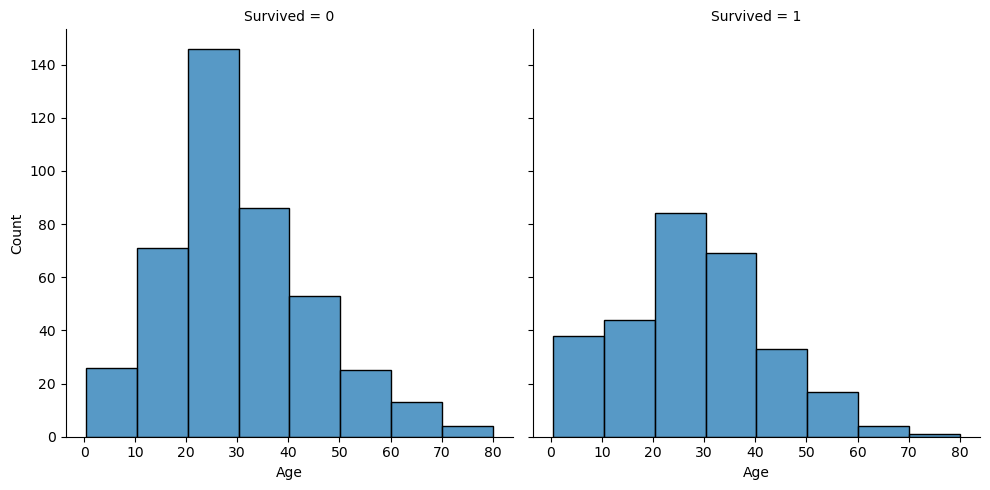

In [16]:
sns.displot(train_df, x='Age', col='Survived', binwidth=10, height=5)

In [17]:
train_df['Age_cut'] = pd.qcut(train_df['Age'], 8)
test_df['Age_cut'] = pd.qcut(test_df['Age'], 8)

In [18]:
train_df.groupby(['Age_cut'], as_index=False)['Survived'].mean()

/tmp/ipykernel_240642/236160506.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Age_cut'], as_index=False)['Survived'].mean()


,Age_cut,Survived
0,"(0.419, 16.0]",0.550000
1,"(16.0, 20.125]",0.341772
2,"(20.125, 24.0]",0.367347
3,"(24.0, 28.0]",0.352941
4,"(28.0, 32.312]",0.416667
5,"(32.312, 38.0]",0.450549
6,"(38.0, 47.0]",0.329545
7,"(47.0, 80.0]",0.415730


In [19]:
train_df.loc[train_df['Age'] <= 16, 'Age'] = 0
train_df.loc[(train_df['Age'] > 16) & (train_df['Age'] <= 20.125), 'Age'] = 1
train_df.loc[(train_df['Age'] > 20.125) & (train_df['Age'] <= 24), 'Age'] = 2
train_df.loc[(train_df['Age'] > 24) & (train_df['Age'] <= 28), 'Age'] = 3
train_df.loc[(train_df['Age'] > 28) & (train_df['Age'] <= 32.312), 'Age'] = 4
train_df.loc[(train_df['Age'] > 32.312) & (train_df['Age'] <= 38), 'Age'] = 5
train_df.loc[(train_df['Age'] > 38) & (train_df['Age'] <= 47), 'Age'] = 6
train_df.loc[(train_df['Age'] > 47) & (train_df['Age'] <= 80), 'Age'] = 7
train_df.loc[train_df['Age'] > 80, 'Age'] = 8

In [20]:
test_df.loc[test_df['Age'] <= 16, 'Age'] = 0
test_df.loc[(test_df['Age'] > 16) & (test_df['Age'] <= 20.125), 'Age'] = 1
test_df.loc[(test_df['Age'] > 20.125) & (test_df['Age'] <= 24), 'Age'] = 2
test_df.loc[(test_df['Age'] > 24) & (test_df['Age'] <= 28), 'Age'] = 3
test_df.loc[(test_df['Age'] > 28) & (test_df['Age'] <= 32.312), 'Age'] = 4
test_df.loc[(test_df['Age'] > 32.312) & (test_df['Age'] <= 38), 'Age'] = 5
test_df.loc[(test_df['Age'] > 38) & (test_df['Age'] <= 47), 'Age'] = 6
test_df.loc[(test_df['Age'] > 47) & (test_df['Age'] <= 80), 'Age'] = 7
test_df.loc[test_df['Age'] > 80, 'Age'] = 8

In [21]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Fam_Size,Fam_Size_Grp,Age_cut
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,7.2500,NaN,S,2,Small,"(20.125, 24.0]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,71.2833,C85,C,2,Small,"(32.312, 38.0]"
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Alone,"(24.0, 28.0]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,53.1000,C123,S,2,Small,"(32.312, 38.0]"
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,8.0500,NaN,S,1,Alone,"(32.312, 38.0]"


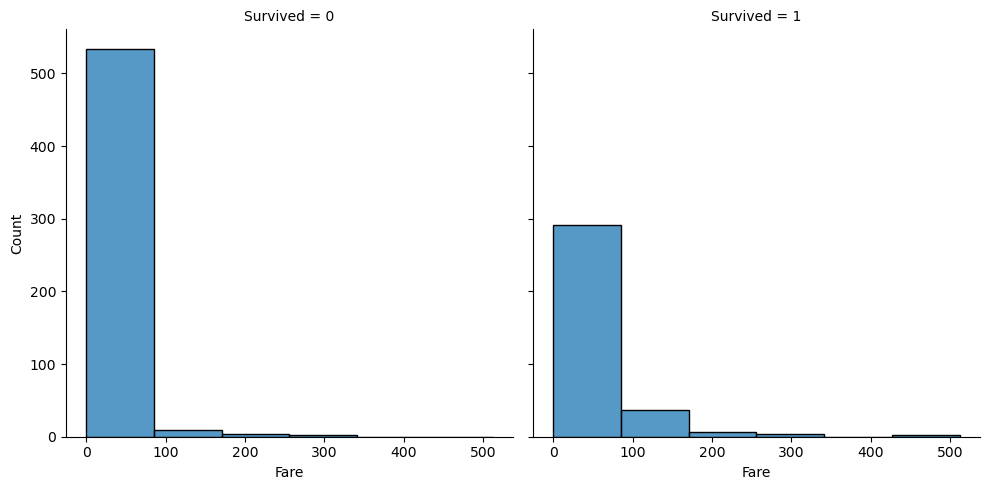

In [22]:
sns.displot(train_df, x = 'Fare', col = 'Survived', binwidth = 80, height = 5)

In [23]:
train_df['Fare_cut'] = pd.qcut(train_df['Fare'], 6)
test_df['Fare_cut'] = pd.qcut(test_df['Fare'], 6)

In [24]:
train_df.groupby(['Fare_cut'], as_index=False)['Survived'].mean()

/tmp/ipykernel_240642/3412529244.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Fare_cut'], as_index=False)['Survived'].mean()


,Fare_cut,Survived
0,"(-0.001, 7.775]",0.205128
1,"(7.775, 8.662]",0.190789
2,"(8.662, 14.454]",0.366906
3,"(14.454, 26.0]",0.436242
4,"(26.0, 52.369]",0.417808
5,"(52.369, 512.329]",0.697987


In [25]:
train_df.loc[train_df['Fare'] <= 7.775, 'Fare'] = 0
train_df.loc[(train_df['Fare'] > 7.775) & (train_df['Fare'] <= 8.662), 'Fare'] = 1
train_df.loc[(train_df['Fare'] > 8.662) & (train_df['Fare'] <= 14.454), 'Fare'] = 2
train_df.loc[(train_df['Fare'] > 14.454) & (train_df['Fare'] <= 26), 'Fare'] = 3
train_df.loc[(train_df['Fare'] > 26) & (train_df['Fare'] <= 52.369), 'Fare'] = 4
train_df.loc[(train_df['Fare'] > 52.369) & (train_df['Fare'] <= 512.329), 'Fare'] = 5
train_df.loc[train_df['Fare'] > 512.329, 'Fare'] = 6


test_df.loc[test_df['Fare'] <= 7.775, 'Fare'] = 0
test_df.loc[(test_df['Fare'] > 7.775) & (test_df['Fare'] <= 8.662), 'Fare'] = 1
test_df.loc[(test_df['Fare'] > 8.662) & (test_df['Fare'] <= 14.454), 'Fare'] = 2
test_df.loc[(test_df['Fare'] > 14.454) & (test_df['Fare'] <= 26), 'Fare'] = 3
test_df.loc[(test_df['Fare'] > 26) & (test_df['Fare'] <= 52.369), 'Fare'] = 4
test_df.loc[(test_df['Fare'] > 52.369) & (test_df['Fare'] <= 512.329), 'Fare'] = 5
test_df.loc[test_df['Fare'] > 512.329, 'Fare'] = 6

In [26]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Fam_Size,Fam_Size_Grp,Age_cut,Fare_cut
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,0.0,NaN,S,2,Small,"(20.125, 24.0]","(-0.001, 7.775]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,5.0,C85,C,2,Small,"(32.312, 38.0]","(52.369, 512.329]"
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,1.0,NaN,S,1,Alone,"(24.0, 28.0]","(7.775, 8.662]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,5.0,C123,S,2,Small,"(32.312, 38.0]","(52.369, 512.329]"
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,1.0,NaN,S,1,Alone,"(32.312, 38.0]","(7.775, 8.662]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,3.0,0,0,211536,2.0,NaN,S,1,Alone,"(24.0, 28.0]","(8.662, 14.454]"
887,888,1,1,"Graham, Miss. Margaret Edith",female,1.0,0,0,112053,4.0,B42,S,1,Alone,"(16.0, 20.125]","(26.0, 52.369]"
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,3.0,NaN,S,4,Medium,NaN,"(14.454, 26.0]"
889,890,1,1,"Behr, Mr. Karl Howell",male,3.0,0,0,111369,4.0,C148,C,1,Alone,"(24.0, 28.0]","(26.0, 52.369]"


In [27]:
train_df['title'] = train_df['Name'].str.split(pat = ",", expand = True)[1].str.split(pat = ".", expand = True)[0].apply(lambda x:x.strip());

In [28]:
test_df['title'] = test_df['Name'].str.split(pat = ",", expand = True)[1].str.split(pat = ".", expand = True)[0].apply(lambda x:x.strip());

In [29]:
train_df.groupby(['title'], as_index=False)['Survived'].mean()

,title,Survived
0,Capt,0.000000
1,Col,0.500000
2,Don,0.000000
3,Dr,0.428571
4,Jonkheer,0.000000
5,Lady,1.000000
6,Major,0.500000
7,Master,0.575000
8,Miss,0.697802
9,Mlle,1.000000


In [30]:
train_df['title'] = train_df['title'].replace({
                                                'Capt' : 'Military',
                                                'Col' : 'Military',
                                                'Major' : 'Military',
                                                'Jonkheer' : 'Noble',
                                                'the Countess': 'Noble',
                                                'Don' : 'Noble',
                                                'Lady' : 'Noble',
                                                'Sir' : 'Noble',
                                                'Mlle' : 'Noble',
                                                'Ms' : 'Noble',
                                                'Mme' : 'Noble'           })
test_df['title'] = test_df['title'].replace({
                                                'Capt' : 'Military',
                                                'Col' : 'Military',
                                                'Major' : 'Military',
                                                'Jonkheer' : 'Noble',
                                                'the Countess': 'Noble',
                                                'Don' : 'Noble',
                                                'Lady' : 'Noble',
                                                'Sir' : 'Noble',
                                                'Mlle' : 'Noble',
                                                'Ms' : 'Noble',
                                                'Mme' : 'Noble'           })

In [31]:
train_df.groupby(['title'], as_index=False)['Survived'].mean()

,title,Survived
0,Dr,0.428571
1,Master,0.575000
2,Military,0.400000
3,Miss,0.697802
4,Mr,0.156673
5,Mrs,0.792000
6,Noble,0.777778
7,Rev,0.000000


In [32]:
train_df.groupby(['title'], as_index=False)['Survived'].agg(['count', 'mean'])

,title,count,mean
0,Dr,7,0.428571
1,Master,40,0.575000
2,Military,5,0.400000
3,Miss,182,0.697802
4,Mr,517,0.156673
5,Mrs,125,0.792000
6,Noble,9,0.777778
7,Rev,6,0.000000


In [33]:
train_df['Name_len'] = train_df['Name'].apply(lambda x:len(x))
test_df['Name_len'] = test_df['Name'].apply(lambda x:len(x))

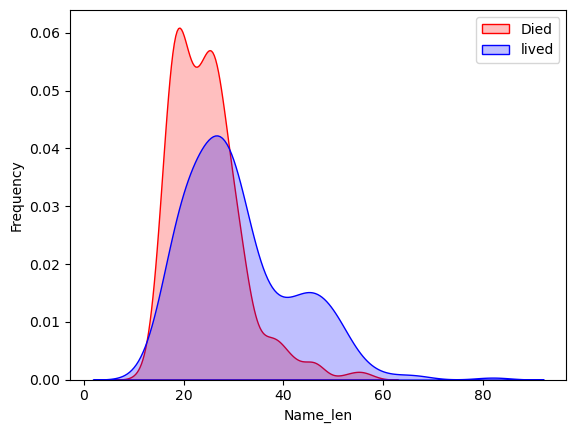

In [34]:
g = sns.kdeplot(train_df['Name_len'][(train_df['Survived'] == 0) & (train_df['Name_len'].notnull())], color = "Red", fill=True)
g = sns.kdeplot(train_df['Name_len'][(train_df['Survived'] == 1) & (train_df['Name_len'].notnull())], color = "Blue", fill=True)
g.set_xlabel("Name_len")
g.set_ylabel("Frequency")
g = g.legend(['Died', 'lived'])

In [35]:
train_df['Name_len_grp'] = pd.qcut(train_df['Name_len'], 8)
test_df['Name_len_grp'] = pd.qcut(test_df['Name_len'], 8)

In [36]:
train_df['Name_len_grp'].dtype

CategoricalDtype(categories=[(11.999, 18.0],   (18.0, 20.0],   (20.0, 23.0],
                    (23.0, 25.0],  (25.0, 27.25],  (27.25, 30.0],
                    (30.0, 38.0],   (38.0, 82.0]],
, ordered=True, categories_dtype=interval[float64, right])

In [37]:
train_df.groupby(['Name_len_grp'], as_index = False)['Survived'].mean()

/tmp/ipykernel_240642/1680452094.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Name_len_grp'], as_index = False)['Survived'].mean()


,Name_len_grp,Survived
0,"(11.999, 18.0]",0.214286
1,"(18.0, 20.0]",0.252427
2,"(20.0, 23.0]",0.307692
3,"(23.0, 25.0]",0.346939
4,"(25.0, 27.25]",0.292929
5,"(27.25, 30.0]",0.428571
6,"(30.0, 38.0]",0.517241
7,"(38.0, 82.0]",0.745283


In [38]:
train_df.loc[train_df['Name_len'] <= 18, 'Name_size'] = 0
train_df.loc[(train_df['Name_len'] > 18) & (train_df['Name_len'] <= 20), 'Name_size'] = 1
train_df.loc[(train_df['Name_len'] > 20) & (train_df['Name_len'] <= 23), 'Name_size'] = 2
train_df.loc[(train_df['Name_len'] > 23) & (train_df['Name_len'] <= 25), 'Name_size'] = 3
train_df.loc[(train_df['Name_len'] > 25) & (train_df['Name_len'] <= 27.25), 'Name_size'] = 4
train_df.loc[(train_df['Name_len'] > 27.25) & (train_df['Name_len'] <= 30), 'Name_size'] = 5
train_df.loc[(train_df['Name_len'] > 30) & (train_df['Name_len'] <= 38), 'Name_size'] = 6
train_df.loc[(train_df['Name_len'] > 38) & (train_df['Name_len'] <= 82), 'Name_size'] = 7
train_df.loc[train_df['Name_len'] > 82, 'Name_size'] = 8


test_df.loc[test_df['Name_len'] <= 18, 'Name_size'] = 0
test_df.loc[(test_df['Name_len'] > 18) & (test_df['Name_len'] <= 20), 'Name_size'] = 1
test_df.loc[(test_df['Name_len'] > 20) & (test_df['Name_len'] <= 23), 'Name_size'] = 2
test_df.loc[(test_df['Name_len'] > 23) & (test_df['Name_len'] <= 25), 'Name_size'] = 3
test_df.loc[(test_df['Name_len'] > 25) & (test_df['Name_len'] <= 27.25), 'Name_size'] = 4
test_df.loc[(test_df['Name_len'] > 27.25) & (test_df['Name_len'] <= 30), 'Name_size'] = 5
test_df.loc[(test_df['Name_len'] > 30) & (test_df['Name_len'] <= 38), 'Name_size'] = 6
test_df.loc[(test_df['Name_len'] > 38) & (test_df['Name_len'] <= 82), 'Name_size'] = 7
test_df.loc[test_df['Name_len'] > 82, 'Name_size'] = 8

In [39]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Fam_Size,Fam_Size_Grp,Age_cut,Fare_cut,title,Name_len,Name_len_grp,Name_size
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,0.0,NaN,S,2,Small,"(20.125, 24.0]","(-0.001, 7.775]",Mr,23,"(20.0, 23.0]",2.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,5.0,C85,C,2,Small,"(32.312, 38.0]","(52.369, 512.329]",Mrs,51,"(38.0, 82.0]",7.0
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,1.0,NaN,S,1,Alone,"(24.0, 28.0]","(7.775, 8.662]",Miss,22,"(20.0, 23.0]",2.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,5.0,C123,S,2,Small,"(32.312, 38.0]","(52.369, 512.329]",Mrs,44,"(38.0, 82.0]",7.0
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,1.0,NaN,S,1,Alone,"(32.312, 38.0]","(7.775, 8.662]",Mr,24,"(23.0, 25.0]",3.0


In [40]:
train_df['Ticket']

0             A/5 21171
1              PC 17599
2      STON/O2. 3101282
3                113803
4                373450
             ...       
886              211536
887              112053
888          W./C. 6607
889              111369
890              370376
Name: Ticket, Length: 891, dtype: object

In [41]:
train_df['Ticket_number'] = train_df['Ticket'].apply(lambda x : pd.Series({'Ticket' : x.split()[-1]}))
test_df['Ticket_number'] = test_df['Ticket'].apply(lambda x : pd.Series({'Ticket' : x.split()[-1]}))

In [42]:
train_df.groupby(['Ticket_number'], as_index = False)['Survived'].agg(['count', 'mean']).sort_values('count', ascending = False)

,Ticket_number,count,mean
94,1601,7,0.714286
196,2343,7,0.000000
464,347082,7,0.000000
468,347088,6,0.000000
358,3101295,6,0.000000
...,...,...,...
276,2667,1,1.000000
278,2669,1,0.000000
279,26707,1,0.000000
280,2671,1,0.000000


In [43]:
train_df.groupby('Ticket_number')['Ticket_number'].transform('count')

0      1
1      1
2      1
3      2
4      1
      ..
886    1
887    1
888    2
889    1
890    1
Name: Ticket_number, Length: 891, dtype: int64

In [44]:
train_df['Ticket_number_counts'] = train_df.groupby('Ticket_number')['Ticket_number'].transform('count')
test_df['Ticket_number_counts'] = test_df.groupby('Ticket_number')['Ticket_number'].transform('count')

In [45]:
train_df.groupby('Ticket_number_counts', as_index = False)['Survived'].agg(['count', 'mean']).sort_values('count', ascending = False)

,Ticket_number_counts,count,mean
0,1,544,0.295956
1,2,188,0.569149
2,3,66,0.712121
3,4,44,0.500000
6,7,21,0.238095
5,6,18,0.000000
4,5,10,0.000000


In [46]:
train_df['Ticket'].str.split(pat = " ", expand = True)

,0,1,2
0,A/5,21171,None
1,PC,17599,None
2,STON/O2.,3101282,None
3,113803,None,None
4,373450,None,None
...,...,...,...
886,211536,None,None
887,112053,None,None
888,W./C.,6607,None
889,111369,None,None


In [47]:
np.where(train_df['Ticket'].str.split(pat = " ", expand = True)[1].notna(), train_df['Ticket'].str.split(pat = " ", expand = True)[0].apply(lambda x : x.strip()), 'Blank')

array(['A/5', 'PC', 'STON/O2.', 'Blank', 'Blank', 'Blank', 'Blank',
       'Blank', 'Blank', 'Blank', 'PP', 'Blank', 'A/5.', 'Blank', 'Blank',
       'Blank', 'Blank', 'Blank', 'Blank', 'Blank', 'Blank', 'Blank',
       'Blank', 'Blank', 'Blank', 'Blank', 'Blank', 'Blank', 'Blank',
       'Blank', 'PC', 'PC', 'Blank', 'C.A.', 'PC', 'Blank', 'Blank',
       'A./5.', 'Blank', 'Blank', 'Blank', 'Blank', 'Blank', 'SC/Paris',
       'Blank', 'S.C./A.4.', 'Blank', 'Blank', 'Blank', 'Blank', 'Blank',
       'A/4.', 'PC', 'Blank', 'Blank', 'Blank', 'C.A.', 'Blank', 'C.A.',
       'CA', 'Blank', 'Blank', 'Blank', 'Blank', 'PC', 'Blank', 'C.A.',
       'S.P.', 'Blank', 'Blank', 'C.A.', 'CA', 'S.O.C.', 'Blank', 'Blank',
       'Blank', 'Blank', 'Blank', 'Blank', 'Blank', 'Blank', 'Blank',
       'Blank', 'Blank', 'SO/C', 'Blank', 'W./C.', 'SOTON/OQ', 'Blank',
       'Blank', 'Blank', 'Blank', 'W.E.P.', 'C.A.', 'Blank', 'Blank',
       'PC', 'PC', 'Blank', 'Blank', 'Blank', 'Blank', 'Blank', 'Blan

In [48]:
train_df['Ticket_location'] = np.where(train_df['Ticket'].str.split(pat = " ", expand = True)[1].notna(), train_df['Ticket'].str.split(pat = " ", expand = True)[0].apply(lambda x : x.strip()), 'Blank')
test_df['Ticket_location'] = np.where(test_df['Ticket'].str.split(pat = " ", expand = True)[1].notna(), test_df['Ticket'].str.split(pat = " ", expand = True)[0].apply(lambda x : x.strip()), 'Blank')

In [49]:
train_df['Ticket_location'].value_counts()

Ticket_location
Blank         665
PC             60
C.A.           27
STON/O         12
A/5            10
W./C.           9
CA.             8
SOTON/O.Q.      8
A/5.            7
SOTON/OQ        7
STON/O2.        6
CA              6
C               5
S.O.C.          5
SC/PARIS        5
F.C.C.          5
SC/Paris        4
A/4.            3
PP              3
A/4             3
S.O./P.P.       3
SC/AH           3
A./5.           2
P/PP            2
A.5.            2
WE/P            2
SOTON/O2        2
S.C./PARIS      2
S.C./A.4.       1
Fa              1
S.O.P.          1
SO/C            1
S.P.            1
A4.             1
W.E.P.          1
A/S             1
SC              1
SW/PP           1
SCO/W           1
W/C             1
S.W./PP         1
F.C.            1
C.A./SOTON      1
Name: count, dtype: int64

In [50]:
train_df['Ticket_location'] = train_df['Ticket_location'].replace({
                                                                    'SOTON/O.Q.':'SOTON/OQ',
                                                                    'C.A.':'CA',
                                                                    'CA.':'CA',
                                                                    'SC/PARIS':'SC/Paris',
                                                                    'S.C./PARIS':'SC/Paris',
                                                                    'A/4.':'A/4',
                                                                    'A/5.':'A/5',
                                                                    'A.5.':'A/5',
                                                                    'A./5.':'A/5',
                                                                    'W./C.':'W/C'
                                                                                            })


test_df['Ticket_location'] = test_df['Ticket_location'].replace({
                                                                    'SOTON/O.Q.':'SOTON/OQ',
                                                                    'C.A.':'CA',
                                                                    'CA.':'CA',
                                                                    'SC/PARIS':'SC/Paris',
                                                                    'S.C./PARIS':'SC/Paris',
                                                                    'A/4.':'A/4',
                                                                    'A/5.':'A/5',
                                                                    'A.5.':'A/5',
                                                                    'A./5.':'A/5',
                                                                    'W./C.':'W/C'
                                                                                            })

In [51]:
train_df.groupby(['Ticket_location'], as_index = False)['Survived'].agg(['count', 'mean'])

,Ticket_location,count,mean
0,A/4,6,0.000000
1,A/5,21,0.095238
2,A/S,1,0.000000
3,A4.,1,0.000000
4,Blank,665,0.383459
5,C,5,0.400000
6,C.A./SOTON,1,0.000000
7,CA,41,0.341463
8,F.C.,1,0.000000
9,F.C.C.,5,0.800000


In [52]:
train_df['Cabin'] = train_df['Cabin'].fillna('U');
train_df['Cabin'] = pd.Series([i[0] if not pd.isnull(i) else 'x' for i in train_df['Cabin']])

test_df['Cabin'] = test_df['Cabin'].fillna('U');
test_df['Cabin'] = pd.Series([i[0] if not pd.isnull(i) else 'x' for i in test_df['Cabin']])

In [53]:
train_df.groupby(['Cabin'], as_index = False)['Survived'].agg(['count', 'mean'])

,Cabin,count,mean
0,A,15,0.466667
1,B,47,0.744681
2,C,59,0.593220
3,D,33,0.757576
4,E,32,0.750000
5,F,13,0.615385
6,G,4,0.500000
7,T,1,0.000000
8,U,687,0.299854


In [54]:
train_df['Cabin_assigned'] = train_df['Cabin'].apply(lambda x : 0 if x in ['U'] else 1)
test_df['Cabin_assigned'] = test_df['Cabin'].apply(lambda x : 0 if x in ['U'] else 1)

In [55]:
train_df.groupby(['Cabin_assigned'], as_index = False)['Survived'].agg(['count', 'mean'])

,Cabin_assigned,count,mean
0,0,687,0.299854
1,1,204,0.666667


In [56]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Age_cut,Fare_cut,title,Name_len,Name_len_grp,Name_size,Ticket_number,Ticket_number_counts,Ticket_location,Cabin_assigned
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,0.0,...,"(20.125, 24.0]","(-0.001, 7.775]",Mr,23,"(20.0, 23.0]",2.0,21171,1,A/5,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,5.0,...,"(32.312, 38.0]","(52.369, 512.329]",Mrs,51,"(38.0, 82.0]",7.0,17599,1,PC,1
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,1.0,...,"(24.0, 28.0]","(7.775, 8.662]",Miss,22,"(20.0, 23.0]",2.0,3101282,1,STON/O2.,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,5.0,...,"(32.312, 38.0]","(52.369, 512.329]",Mrs,44,"(38.0, 82.0]",7.0,113803,2,Blank,1
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,1.0,...,"(32.312, 38.0]","(7.775, 8.662]",Mr,24,"(23.0, 25.0]",3.0,373450,1,Blank,0


In [57]:
train_df.shape

(891, 24)

In [58]:
test_df.shape

(418, 23)

In [59]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   PassengerId           891 non-null    int64   
 1   Survived              891 non-null    int64   
 2   Pclass                891 non-null    int64   
 3   Name                  891 non-null    object  
 4   Sex                   891 non-null    object  
 5   Age                   714 non-null    float64 
 6   SibSp                 891 non-null    int64   
 7   Parch                 891 non-null    int64   
 8   Ticket                891 non-null    object  
 9   Fare                  891 non-null    float64 
 10  Cabin                 891 non-null    object  
 11  Embarked              889 non-null    object  
 12  Fam_Size              891 non-null    int64   
 13  Fam_Size_Grp          891 non-null    object  
 14  Age_cut               714 non-null    category
 15  Fare_c

In [60]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   PassengerId           418 non-null    int64   
 1   Pclass                418 non-null    int64   
 2   Name                  418 non-null    object  
 3   Sex                   418 non-null    object  
 4   Age                   332 non-null    float64 
 5   SibSp                 418 non-null    int64   
 6   Parch                 418 non-null    int64   
 7   Ticket                418 non-null    object  
 8   Fare                  417 non-null    float64 
 9   Cabin                 418 non-null    object  
 10  Embarked              418 non-null    object  
 11  Fam_Size              418 non-null    int64   
 12  Fam_Size_Grp          418 non-null    object  
 13  Age_cut               332 non-null    category
 14  Fare_cut              417 non-null    category
 15  title 

In [61]:
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].mean())
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].mean())
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].mean())

In [62]:
ohe = OneHotEncoder(sparse_output = False)
ode = OrdinalEncoder
SI = SimpleImputer(strategy = 'most_frequent')

In [63]:
ode_col = ['Fam_Size_Grp']
ohe_col = ['Sex', 'Embarked']

In [64]:
X = train_df.drop(['Survived'], axis = 1)
Y = train_df['Survived']
X_test = test_df.drop(['Age_cut', 'Fare_cut'], axis = 1)

In [65]:
X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, test_size = 0.2, stratify = Y, random_state = 21)

In [66]:
ordinal_pipeline = Pipeline(steps = [
                                        ('impute', SimpleImputer(strategy = 'most_frequent')),
                                        ('ord', OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value = -1))
                                                                                                                            ])

ohe_pipeline = Pipeline(steps = [
                                        ('impute', SimpleImputer(strategy = 'most_frequent')),
                                        ('one-hot', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False))
                                                                                                                            ])

In [67]:
col_transform = ColumnTransformer( transformers = [
                                                    ('impute', SI, ['Age']),
                                                    ('ord_pipeline', ordinal_pipeline, ode_col),
                                                    ('ohe_pipeline', ohe_pipeline, ohe_col),
                                                    ('passthrough', 'passthrough', ['Pclass', 'Ticket_number_counts', 'Cabin_assigned', 'Name_size', 'Age', 'Fare'])
                                                                                                                                                                    ],
                                   remainder = 'drop',
                                   
                                   n_jobs = -1
                                                                                                                                                                      )

In [68]:
rfc = RandomForestClassifier()

In [69]:
param_grid = {
                'n_estimators' : [100, 150, 200],
                'min_samples_split' : [5, 10, 15],
                'max_depth' : [8, 9, 10, 15, 20],
                'min_samples_leaf' : [1, 2, 4],
                'criterion' : ['gini', 'entropy']
                                                    }

In [70]:
CV_rfc = GridSearchCV( estimator = rfc, param_grid = param_grid, cv = StratifiedKFold(n_splits = 5))

In [71]:
pipefinalrfc = make_pipeline(col_transform, CV_rfc)
pipefinalrfc.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of 

In [72]:
print(CV_rfc.best_params_)
print(CV_rfc.best_score_)

{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
0.8230572244656752


In [73]:
dtc = DecisionTreeClassifier()

In [74]:
param_grid = {
                'min_samples_split' : [5, 10, 15],
                'max_depth' : [10, 20, 30],
                'min_samples_leaf' : [1, 2, 4],
                'criterion' : ['gini', 'entropy'] 
                                                    }

In [75]:
CV_dtc = GridSearchCV(estimator = dtc, param_grid = param_grid, cv = StratifiedKFold(n_splits = 5))

In [76]:
pipefinaldtc = make_pipeline(col_transform, CV_dtc)
pipefinaldtc.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of 

In [77]:
print(CV_dtc.best_params_)
print(CV_dtc.best_score_)

{'criterion': 'gini', 'max_depth': 30, 'min_samples_leaf': 4, 'min_samples_split': 10}
0.8103713188220232


In [78]:
knn = KNeighborsClassifier()

In [79]:
param_grid = {
                'n_neighbors' : [3, 5 ,7 , 9, 11],
                'weights' : ['uniform', 'distance'],
                'algorithm' : ['auto', 'ball_tree', 'kd_tree', 'brute'],
                'p' : [1, 2]
                                                                            }

In [80]:
CV_knn = GridSearchCV(estimator = knn, param_grid = param_grid, cv = StratifiedKFold(n_splits = 5))

In [81]:
pipefinalknn = make_pipeline(col_transform, CV_knn)
pipefinalknn.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of 

In [82]:
print(CV_knn.best_params_)
print(CV_knn.best_score_)

{'algorithm': 'brute', 'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}
0.807593814636068


In [83]:
svc = SVC()

In [84]:
param_grid = {
                'C' : [100, 10, 1, 0.1, 0.001],
                'kernel' : ['linear', 'poly', 'rbf', 'sigmoid']
                                                                }

In [85]:
CV_svc = GridSearchCV( estimator = svc, param_grid = param_grid, cv = StratifiedKFold(n_splits = 5))

In [86]:
pipefinalsvc = make_pipeline(col_transform, CV_svc)
pipefinalsvc.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of 

In [87]:
print(CV_svc.best_params_)
print(CV_svc.best_score_)

{'C': 10, 'kernel': 'poly'}
0.8188121737417513


In [88]:
lr = LogisticRegression()

In [89]:
param_grid = {
                'C' : [100, 10, 1, 0.1, 0.001]
                                                }

In [90]:
CV_lr = GridSearchCV(estimator = lr, param_grid = param_grid, cv = StratifiedKFold(n_splits = 5))

In [91]:
pipefinallr = make_pipeline(col_transform, CV_lr)
pipefinallr.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of 

In [92]:
print(CV_lr.best_params_)
print(CV_lr.best_score_)

{'C': 0.1}
0.8020092583472864


In [93]:
gnb = GaussianNB()

In [94]:
param_grid = {
                'var_smoothing': [1e-07, 1e-08, 1e-09]
                                                        }

In [95]:
CV_gnb = GridSearchCV(estimator = gnb, param_grid = param_grid, cv = StratifiedKFold(n_splits = 10))

In [96]:
pipefinalgnb = make_pipeline(col_transform, CV_gnb)
pipefinalgnb.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of 

In [97]:
print(CV_gnb.best_params_)
print(CV_gnb.best_score_)

{'var_smoothing': 1e-07}
0.7823748043818466


In [98]:
Y_pred1 = pipefinaldtc.predict(X_test)
Y_pred2 = pipefinalgnb.predict(X_test)
Y_pred3 = pipefinalknn.predict(X_test)
Y_pred4 = pipefinallr.predict(X_test)
Y_pred5 = pipefinalrfc.predict(X_test)
Y_pred6 = pipefinalsvc.predict(X_test)

In [116]:
def Submission_generator ( Y_pred, number):
    Submission = pd.DataFrame({
                                'PassengerId' : test_df['PassengerId'],
                                'Survived' : Y_pred
                                                                        })
    Submission.to_csv('./submissions/submission_hawk_%03d.csv' %number, index = False)
    return

In [117]:
Submission_generator(Y_pred1,1)
Submission_generator(Y_pred2,2)
Submission_generator(Y_pred3,3)
Submission_generator(Y_pred4,4)
Submission_generator(Y_pred5,5)
Submission_generator(Y_pred6,6)